In [4]:
# 1. Part globale des jours à 0 vente
zero_total = (df["sales"] == 0).mean()
print("Part des lignes à 0 vente :", round(zero_total * 100, 1), "%")
print()

# 2. Pour chaque produit : quelle part de ses jours est à 0 ?
zero_by_item = (
    df.assign(is_zero=df["sales"] == 0)
      .groupby("item_id")["is_zero"]
      .mean()
)

# 3. Ranger les produits en 4 groupes
groupes = pd.cut(
    zero_by_item,
    bins=[0, 0.2, 0.5, 0.8, 1.0],
    labels=["Quotidien (< 20 % de 0)",
            "Régulier (20-50 %)",
            "Irrégulier (50-80 %)",
            "Rare (> 80 % de 0)"],
    include_lowest=True
)

print(groupes.value_counts().sort_index())

Part des lignes à 0 vente : 55.2 %

is_zero
Quotidien (< 20 % de 0)     229
Régulier (20-50 %)          959
Irrégulier (50-80 %)       1370
Rare (> 80 % de 0)          491
Name: count, dtype: int64


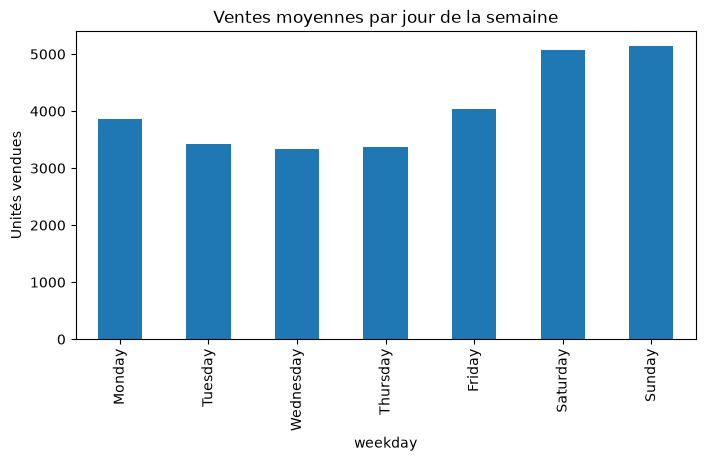

In [3]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

daily_df = df.groupby(["date", "weekday"])["sales"].sum().reset_index()
by_day = daily_df.groupby("weekday")["sales"].mean().reindex(order)

by_day.plot(kind="bar", figsize=(8, 4), title="Ventes moyennes par jour de la semaine")
plt.ylabel("Unités vendues")
plt.show()

In [2]:
daily.nsmallest(5)

date
2011-12-25    0
2012-12-25    0
2013-12-25    0
2014-12-25    0
2015-12-25    0
Name: sales, dtype: int64

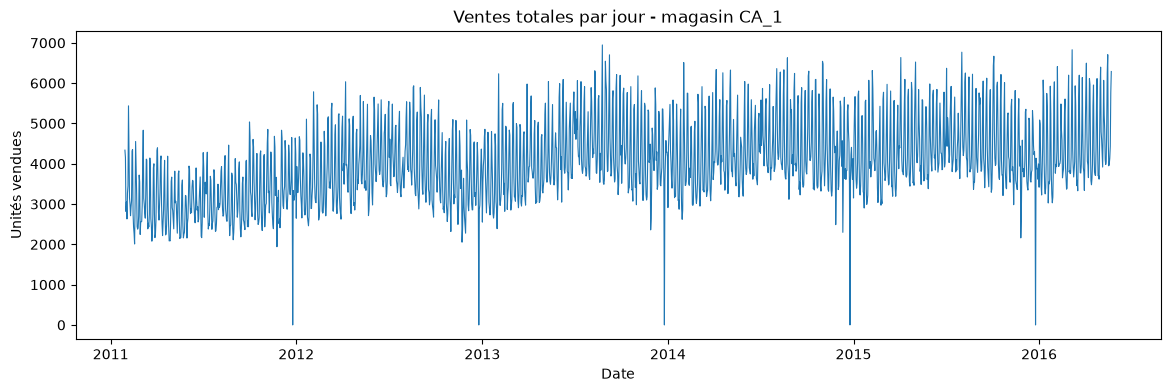

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/sales_ca1_clean.parquet")

daily = df.groupby("date")["sales"].sum()

plt.figure(figsize=(14, 4))
plt.plot(daily.index, daily.values, linewidth=0.8)
plt.title("Ventes totales par jour - magasin CA_1")
plt.xlabel("Date")
plt.ylabel("Unités vendues")
plt.show()